<!-- open-in-badges -->
[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EAFIT-IA/si7011-DeepLearning/blob/main/sessions/02_deep_training/notebooks/sesion_02_5_optuna_mlflow.ipynb) [![Abrir en Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/EAFIT-IA/si7011-DeepLearning/blob/main/sessions/02_deep_training/notebooks/sesion_02_5_optuna_mlflow.ipynb) [![Abrir en Lightning Studio](https://pl-bolts-doc-images.s3.us-east-2.amazonaws.com/app-2/studio-badge.svg)](https://lightning.ai/new?repo_url=https%3A%2F%2Fgithub.com%2FEAFIT-IA%2Fsi7011-DeepLearning%2Fblob%2Fmain%2Fsessions%2F02_deep_training%2Fnotebooks%2Fsesion_02_5_optuna_mlflow.ipynb)

# SI7011 · Sesión 02 · 5. Búsqueda de hiperparámetros con Optuna y MLflow
**Juan David Martínez Vargas · Universidad EAFIT**

| Sección | Lo que cambia | Qué mirar |
|---|---|---|
| 1 | MLflow: registrar una corrida | parámetros, curvas y la tabla de corridas |
| 2 | espacio de búsqueda | escala logarítmica para η y weight decay |
| 3 | objetivo con *pruning* | cortar intentos que ya van mal |
| 4 | el estudio: TPE + poda por mediana | intentos completos y podados |
| 5 | analizar en MLflow y Optuna | qué hiperparámetro importó |
| 6 | reentrenar y evaluar en prueba una vez | por qué el mejor valor de la búsqueda es optimista |

Es el ejemplo resuelto de MLflow que se usa en el ejercicio integrador (notebook 6). Corre en CPU en 1–2 minutos (Colab, Kaggle, Lightning o local).

In [1]:
%pip install -q mlflow optuna

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy, math, time
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import torch
from torch import nn
from torchvision import datasets

torch.manual_seed(0)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
int_epochs = lambda: plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
print('PyTorch', torch.__version__)

PyTorch 2.14.1+cu130


## Datos: Fashion-MNIST como vectores
Son los mismos datos en los cuatro notebooks de la sesión. Cada imagen de 28×28 se aplana en un vector de 784 valores. Se usan 10 000 ejemplos de entrenamiento, 10 000 de validación (tomados del resto del conjunto de entrenamiento) y el conjunto de prueba oficial. El escalado se calcula **solo** con entrenamiento.

In [3]:
train_set = datasets.FashionMNIST('data', train=True, download=True)
test_set = datasets.FashionMNIST('data', train=False, download=True)
CLASSES = train_set.classes

# imagen 28×28 → vector x ∈ ℝ⁷⁸⁴ con píxeles en [0, 1]
X = train_set.data.reshape(-1, 784).float() / 255
y = train_set.targets  # y ∈ {0, …, 9}: C = 10 clases
perm = torch.randperm(len(X), generator=torch.Generator().manual_seed(0))
# entrenamiento: con estos ejemplos se calcula ∇J
X_train, y_train = X[perm[:10_000]], y[perm[:10_000]]
X_val, y_val = X[perm[50_000:]], y[perm[50_000:]]  # validación: J_val, para comparar decisiones
# prueba: se usa una sola vez, al final
X_test, y_test = test_set.data.reshape(-1, 784).float() / 255, test_set.targets

# Estandarizar deja las entradas con media 0 y varianza 1. Las fórmulas de inicialización
# suponen esa escala: Var(z_1) = n_in · Var(W_1) · E[a_0²] con a_0 = x.
mu, sd = X_train.mean(), X_train.std()          # estadísticas solo de entrenamiento
X_train, X_val, X_test = [(t - mu) / sd for t in (X_train, X_val, X_test)]
X_train.shape, X_val.shape, X_test.shape

(torch.Size([10000, 784]), torch.Size([10000, 784]), torch.Size([10000, 784]))

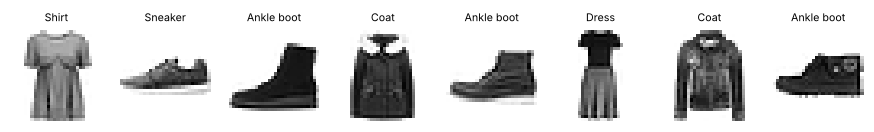

In [4]:
fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
for ax, img, lab in zip(axes, train_set.data[perm[:8]], train_set.targets[perm[:8]]):
    ax.imshow(img, cmap='gray_r'); ax.set_title(CLASSES[lab], fontsize=7); ax.axis('off')
plt.show()

## Herramientas: entrenar, evaluar y graficar
Es el mismo loop de la sesión 01 y se define una sola vez. Lo que cambia en cada sección es el **modelo** o el **optimizador**.

In [5]:
# L_i = −log softmax(f_θ(x_i))_{y_i}; recibe logits y aplica log_softmax por dentro
loss_fn = nn.CrossEntropyLoss()

def train_epoch(model, opt, batch_size=128):
    model.train()  # modo entrenamiento: Dropout activo, BatchNorm con estadísticas del lote
    perm = torch.randperm(len(X_train))  # orden nuevo en cada época → mini-lotes 𝓑_t distintos
    total = 0.0
    for i in range(0, len(X_train), batch_size):
        b = perm[i:i + batch_size]  # índices del mini-lote 𝓑_t
        loss = loss_fn(model(X_train[b]), y_train[b])  # J_𝓑(θ) = (1/|𝓑|) Σ_{i∈𝓑} L_i(θ)
        # borrar g anterior · g_t = ∇_θ J_𝓑 (backprop) · θ ← regla del optimizador
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item() * len(b)  # promedio de la época ≈ J sobre entrenamiento
    return total / len(X_train)

@torch.no_grad()  # sin grafo: al evaluar no hay backward
def evaluate(model, X, y):
    model.eval()  # modo evaluación: Dropout apagado, BatchNorm con promedios móviles
    logits = model(X)
    # J_val y accuracy; la clase predicha es argmax de los logits (softmax no cambia el orden)
    return loss_fn(logits, y).item(), (logits.argmax(1) == y).float().mean().item()

## Un modelo configurable
En los notebooks 1–4 escribimos cada arquitectura de forma explícita. Aquí la arquitectura **es** lo que se busca, así que pasa a ser una función de sus hiperparámetros. Cada pieza ya la conoces: He (notebook 1), BatchNorm y Dropout (notebook 3).

In [6]:
def make_model(depth, width, dropout, batchnorm):
    layers, n_in = [], 784
    for _ in range(depth):
        # bloque de los notebooks 1 y 3: Linear → [BatchNorm] → ReLU → Dropout
        layers += [nn.Linear(n_in, width)] + ([nn.BatchNorm1d(width)] if batchnorm else []) + [nn.ReLU(), nn.Dropout(dropout)]
        n_in = width
    model = nn.Sequential(*layers, nn.Linear(width, 10))
    for m in model:
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu'); nn.init.zeros_(m.bias)
    return model

def train(params, epochs=6, on_epoch=None):
    torch.manual_seed(0)
    model = make_model(params['depth'], params['width'], params['dropout'], params['batchnorm'])
    # AdamW (notebook 3): λ = weight_decay es una dimensión más de la búsqueda
    opt = torch.optim.AdamW(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
    hist, best = {'loss': [], 'val_loss': [], 'val_acc': []}, (float('inf'), None)
    for epoch in range(epochs):
        hist['loss'].append(train_epoch(model, opt, params['batch_size']))
        val_loss, val_acc = evaluate(model, X_val, y_val)
        hist['val_loss'].append(val_loss); hist['val_acc'].append(val_acc)
        if val_loss < best[0]:
            # early stopping (notebook 3): se guarda θ*
            best = (val_loss, copy.deepcopy(model.state_dict()))
        if on_epoch is not None:
            on_epoch(epoch, val_loss)            # aquí se conecta Optuna (sección 3)
    model.load_state_dict(best[1])
    return model, hist

## 1. MLflow: registrar una corrida
Sin un registro, después de 20 experimentos nadie recuerda qué configuración produjo qué curva. MLflow guarda cada **corrida** con tres cosas:

- `log_params`: la configuración;
- `log_metric(..., step=epoch)`: las curvas;
- `log_artifact`: archivos como el modelo.

Todo queda en `mlflow.db`, una base SQLite local.

In [7]:
import os
os.environ.setdefault('MLFLOW_DISABLE_AGENT_HINT', '1')
import logging
import mlflow, optuna
logging.getLogger('mlflow').setLevel(logging.WARNING)

mlflow.set_tracking_uri('sqlite:///mlflow.db')
EXPERIMENT = 'S02-fashion-optuna'
mlflow.set_experiment(EXPERIMENT)

# λ: el vector de hiperparámetros. La búsqueda resuelve λ* = argmin_λ J_val(θ*(λ))
BASE = dict(depth=2, width=256, dropout=0.0, batchnorm=False, lr=1e-3, weight_decay=1e-2, batch_size=128)

def log_history(hist):
    for epoch in range(len(hist['loss'])):
        # una curva por métrica, con step = época
        mlflow.log_metrics({k: v[epoch] for k, v in hist.items()}, step=epoch)

with mlflow.start_run(run_name='linea-base'):
    mlflow.log_params(BASE)
    model, hist = train(BASE)
    log_history(hist)
    mlflow.log_metric('best_val_loss', min(hist['val_loss']))
print(f"línea base: mejor val_loss {min(hist['val_loss']):.4f}")

/usr/local/lib/python3.13/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


línea base: mejor val_loss 0.4156


In [8]:
mlflow.search_runs(experiment_names=[EXPERIMENT])[['tags.mlflow.runName', 'params.lr', 'params.depth', 'metrics.best_val_loss']]

,tags.mlflow.runName,params.lr,params.depth,metrics.best_val_loss
0,linea-base,0.001,2,0.41563


## 2. El espacio de búsqueda
$\lambda^\star = \arg\min_\lambda J_\text{val}(\theta^\star(\lambda))$. Cada llamada a `trial.suggest_*` define una dimensión. `lr` y `weight_decay` se muestrean en **escala logarítmica**: entre $10^{-4}$ y $10^{-2}$ importa el orden de magnitud, no la diferencia absoluta.

In [9]:
def search_space(trial):
    return {
        # log: cada orden de magnitud con la misma probabilidad
        'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        # λ de AdamW, también en escala log
        'weight_decay': trial.suggest_float('weight_decay', 1e-4, 1.0, log=True),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'depth': trial.suggest_int('depth', 1, 4),
        'width': trial.suggest_categorical('width', [128, 256, 512]),
        'batchnorm': trial.suggest_categorical('batchnorm', [False, True]),
        'batch_size': trial.suggest_categorical('batch_size', [64, 128, 256]),
    }

In [10]:
import numpy as np
u = np.random.default_rng(0).uniform(1e-4, 1e-2, 10_000)
print(f'muestreo uniforme:     {(u < 1e-3).mean():.0%} de los valores de η caen por debajo de 1e-3')
print(f'muestreo logarítmico:  {(10 ** np.random.default_rng(0).uniform(-4, -2, 10_000) < 1e-3).mean():.0%}')

muestreo uniforme:     9% de los valores de η caen por debajo de 1e-3
muestreo logarítmico:  50%


## 3. El objetivo, con *pruning* y una corrida de MLflow por intento
`objective` recibe un `trial`, entrena y devuelve el número a minimizar. Dos detalles:

- **Pruning.** Después de cada época, `trial.report` le pasa a Optuna la `val_loss` actual. Si el intento va peor que la mediana de los anteriores en esa misma época, `trial.should_prune()` responde `True` y se corta lanzando `optuna.TrialPruned`.
- **Corridas anidadas.** Cada intento es una corrida *hija* (`nested=True`) de la corrida del estudio, así MLflow los agrupa.

In [11]:
def objective(trial):
    params = search_space(trial)
    with mlflow.start_run(run_name=f'intento-{trial.number:02d}', nested=True):
        mlflow.log_params(params)

        def on_epoch(epoch, val_loss):
            mlflow.log_metric('val_loss', val_loss, step=epoch)
            trial.report(val_loss, epoch)  # J_val del intento en esta época
            # ¿peor que la mediana de los intentos anteriores en esta misma época?
            if trial.should_prune():
                mlflow.set_tag('estado', 'PODADO')
                raise optuna.TrialPruned()

        model, hist = train(params, on_epoch=on_epoch)
        mlflow.set_tag('estado', 'COMPLETO')
        mlflow.log_metric('best_val_loss', min(hist['val_loss']))
        return min(hist['val_loss'])  # lo que Optuna minimiza: J_val(θ*(λ))

## 4. El estudio
- **TPE** propone el siguiente $\lambda$ a partir de los intentos anteriores; los 5 primeros son aleatorios.
- **MedianPruner** no poda nada en los 5 primeros intentos ni en la primera época.

Son 20 intentos de 6 épocas; tarda menos de un minuto en CPU.

In [12]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
# TPE modela qué λ dieron J_val bajo y propone el siguiente cerca de ellos
study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=0, n_startup_trials=5),
                            pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1))
t0 = time.time()
with mlflow.start_run(run_name='estudio') as parent:
    study.optimize(objective, n_trials=20)
    mlflow.log_params({f'best_{k}': v for k, v in study.best_params.items()})
    mlflow.log_metric('best_val_loss', study.best_value)

states = [t.state.name for t in study.trials]
print(f"{len(states)} intentos en {time.time() - t0:.0f} s · completos {states.count('COMPLETE')} · podados {states.count('PRUNED')}")
print(f"mejor val_loss {study.best_value:.4f} (línea base {min(hist['val_loss']):.4f})")
study.best_params

20 intentos en 44 s · completos 10 · podados 10
mejor val_loss 0.3856 (línea base 0.4156)


{'lr': 0.0018996964398611724,
 'weight_decay': 0.0018860360699139867,
 'dropout': 0.06744059921703532,
 'depth': 3,
 'width': 256,
 'batchnorm': True,
 'batch_size': 128}

## 5. Analizar los resultados
Desde MLflow: las corridas hijas del estudio, ordenadas.

In [13]:
trials = mlflow.search_runs(experiment_names=[EXPERIMENT], filter_string=f"tags.mlflow.parentRunId = '{parent.info.run_id}'")
cols = ['tags.mlflow.runName', 'tags.estado', 'params.lr', 'params.weight_decay', 'params.dropout', 'params.depth',
        'params.width', 'params.batchnorm', 'params.batch_size', 'metrics.best_val_loss']
table = trials[cols].rename(columns=lambda c: c.split('.', 1)[1])
for c in ['lr', 'weight_decay', 'dropout']:
    table[c] = table[c].astype(float).round(4)
table.sort_values('best_val_loss').head(8)

,mlflow.runName,estado,lr,weight_decay,dropout,depth,width,batchnorm,batch_size,best_val_loss
7,intento-12,COMPLETO,0.0019,0.0019,0.0674,3,256,True,128,0.385559
1,intento-18,COMPLETO,0.0010,0.0019,0.1457,2,128,True,128,0.387439
6,intento-13,COMPLETO,0.0036,0.0001,0.1964,2,512,True,128,0.395892
19,intento-00,COMPLETO,0.0013,0.0726,0.3014,3,256,True,128,0.397942
9,intento-10,COMPLETO,0.0013,0.0003,0.0092,2,256,True,128,0.400490
16,intento-03,COMPLETO,0.0017,0.0294,0.4719,3,512,True,64,0.402287
11,intento-08,COMPLETO,0.0030,0.0392,0.1171,3,512,True,64,0.416052
18,intento-01,COMPLETO,0.0014,0.5039,0.0355,1,256,True,64,0.421605


Desde Optuna: la historia de la búsqueda y la importancia de cada hiperparámetro.

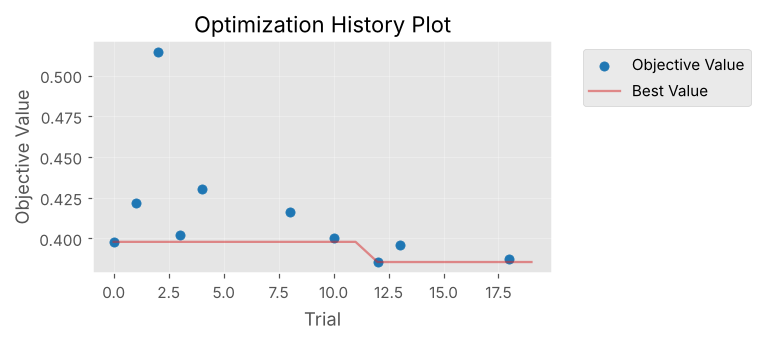

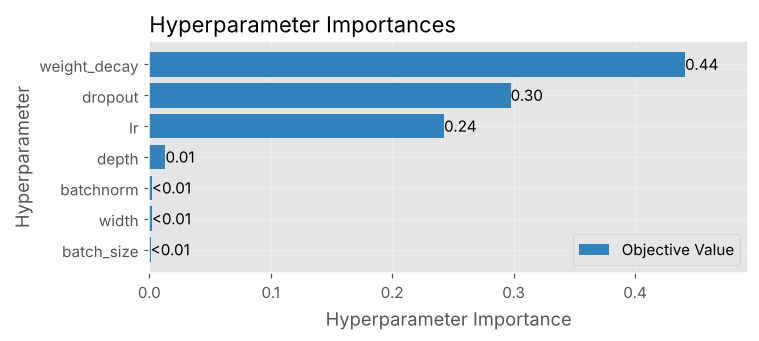

In [14]:
import warnings
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
warnings.filterwarnings('ignore', category=optuna.exceptions.ExperimentalWarning)
for plot in (plot_optimization_history, plot_param_importances):
    ax = plot(study); ax.figure.set_size_inches(7, 3.2); ax.figure.tight_layout(); plt.show()

Lee la importancia con cuidado: 20 intentos son pocos y el número cambia con la semilla. Sirve para decidir **dónde** buscar mejor en la siguiente ronda, no como una medida exacta.

**En la interfaz de MLflow** (opcional, en local): `mlflow ui --backend-store-uri sqlite:///mlflow.db`. Selecciona las corridas hijas, elige *Compare* y luego *Parallel Coordinates Plot*.

## 6. Reentrenar la mejor configuración y evaluar en prueba una sola vez
El mejor `val_loss` del estudio es **optimista**: elegimos el mínimo de 20 números con ruido, así que parte de esa ventaja es suerte. Por eso la prueba, que no participó en ninguna decisión, se usa una sola vez al final.

In [15]:
best_params = {**BASE, **study.best_params}
with mlflow.start_run(run_name='mejor-receta'):
    mlflow.log_params(best_params)
    best_model, best_hist = train(best_params, epochs=10)
    log_history(best_hist)
    # la prueba no participó en la búsqueda: estimación honesta del error de λ* (una sola vez)
    test_loss, test_acc = evaluate(best_model, X_test, y_test)
    mlflow.log_metrics({'best_val_loss': min(best_hist['val_loss']), 'test_loss': test_loss, 'test_acc': test_acc})
    torch.save(best_model.state_dict(), 'best.pt'); mlflow.log_artifact('best.pt')

base_test = evaluate(model, X_test, y_test)
print(f'línea base   · prueba: loss {base_test[0]:.3f} · acc {base_test[1]:.3f}')
print(f'mejor receta · prueba: loss {test_loss:.3f} · acc {test_acc:.3f}')

línea base   · prueba: loss 0.442 · acc 0.840
mejor receta · prueba: loss 0.410 · acc 0.853


## Tu turno · 10 minutos
1. Cambia `TPESampler` por `optuna.samplers.RandomSampler(seed=0)` y repite con los mismos 20 intentos. ¿Cuál encuentra mejor `val_loss`?
2. Quita el pruner (`optuna.pruners.NopPruner()`). ¿Cuánto más tarda el estudio? ¿Encuentra algo mejor?
3. Agrega una dimensión: el optimizador (`trial.suggest_categorical('opt', ['adamw', 'sgd'])`). Tendrás que ajustar `train`.
4. Con la importancia de la sección 5, reduce el espacio: fija los hiperparámetros que no importaron y busca solo en los que sí.

**Para pensar.** Si corres 1000 intentos y eliges el mejor por validación, ¿qué pasa con la distancia entre `best_val_loss` y la pérdida de prueba?

In [16]:
# Experimento 1: RandomSampler frente a TPE


### Referencias
- Akiba et al. (2019), *Optuna: A Next-generation Hyperparameter Optimization Framework*, KDD.
- Bergstra et al. (2011), *Algorithms for Hyper-Parameter Optimization* (TPE), NeurIPS · Bergstra y Bengio (2012), *Random Search for Hyper-Parameter Optimization*, JMLR.
- [MLflow Tracking](https://mlflow.org/docs/latest/ml/tracking/) · [Optuna · pruners](https://optuna.readthedocs.io/en/stable/reference/pruners.html).